<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
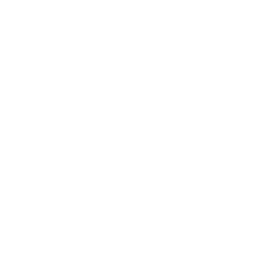
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interpolación de reclutamiento trimestral a mensual</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacéutica / Operaciones clínicas &nbsp;|&nbsp; marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Este ejemplo práctico convierte recuentos **trimestrales** de reclutamiento de un ensayo clínico en estimaciones **mensuales** con PROC EXPAND, de modo que la planificación de recursos a nivel de centro pueda ejecutarse con una cadencia mensual. El ensayo sintético abarca **cuatro centros de investigadores** en dos regiones (Norteamérica y Europa) a lo largo de **ocho trimestres** (del Q1 2024 al Q4 2025), lo que da **32 observaciones trimestrales**. PROC EXPAND interpola la serie de cada centro de frecuencia trimestral a mensual, transformando esas 32 filas trimestrales en **96 filas mensuales**. Los recuentos de reclutamiento se interpolan con `METHOD=JOIN` (lineal por tramos, que mantiene toda estimación no negativa) y el acumulado corrido se interpola con `METHOD=SPLINE`. La serie mensual interpolada pasa exactamente por los puntos de anclaje trimestrales originales, de modo que la conversión añade detalle intratrimestral sin alterar las cifras trimestrales que el estudio ya había reportado.

## Fuentes de datos

| Fuente | Descripción | Registros |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Recuentos trimestrales de reclutamiento por centro (4 centros x 8 trimestres) | 32 |
| WORK.SITE_MASTER | Referencia de centros: nombre, país, región, IP | 4 |

---

In [1]:
/* --------------------------------------------------------
   Generar recuentos trimestrales de inscripción por centro.
   4 centros x 8 trimestres (T1-2024 a T4-2025) = 32 filas.
   Una curva de arranque (inicio lento, meseta) más un término
   estacional leve y ruido pequeño produce una forma de
   inscripción realista.
   -------------------------------------------------------- */
DATOS work.enrollment_qtr;
    LLAMAR streaminit(42);
    FORMATO quarter_date yyq7.;
    LONGITUD region $24;
    ARREGLO capacity[4] _temporary_ (12 9 14 8);
    HACER site_num = 1 HASTA 4;
        site_id = cat('SITE-', PUT(site_num, z3.));
        region  = ifc(site_num <= 2, 'AMÉRICA_DEL_NORTE', 'EUROPA');
        base_rate = capacity[site_num];
        HACER qtr_seq = 0 HASTA 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            SALIDA;
        END;
    END;
    ELIMINAR site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
EJECUTAR;

/* Inscripción acumulada corriente dentro de cada centro */
PROCEDIMIENTO ORDENAR DATOS=work.enrollment_qtr;
    POR site_id quarter_date;
EJECUTAR;

DATOS work.enrollment_qtr;
    ESTABLECER work.enrollment_qtr;
    POR site_id;
    RETENER cum_enrolled 0;
    SI first.site_id ENTONCES cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    ELIMINAR cum_enrolled;
EJECUTAR;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Tabla maestra de referencia de centros (4 centros, 2 regiones)
   -------------------------------------------------------- */
DATOS work.site_master;
    LONGITUD site_id $8 site_name $50 region $24 country $20 pi_name $30;
    ARREGLO names[4] $50 _temporary_ (
        'Hospital General Metropolitano'   'Centro Médico Universitario'
        'Enfermería Real de Londres'   'Campus Charité de Berlín'
    );
    ARREGLO countries[4] $20 _temporary_ ('Estados Unidos' 'Estados Unidos' 'Reino Unido' 'Alemania');
    HACER i = 1 HASTA 4;
        site_id   = cat('SITE-', PUT(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'AMÉRICA_DEL_NORTE', 'EUROPA');
        pi_name   = cat('Dr. Investigador-', PUT(i, z2.));
        SALIDA;
    END;
    ELIMINAR i;
EJECUTAR;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Resumen inicial de inscripción trimestral por región
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.enrollment_qtr n sum mean MAX;
    CLASE region;
    VAR enrolled_count cumulative_enrolled;
    ETIQUETA region = "Región"
          enrolled_count = "Inscritos por trimestre"
          cumulative_enrolled = "Inscritos acumulados";
    SALIDA out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.qtr_baseline noobs ETIQUETA;
    ETIQUETA region = "Región"
          total_enrolled = "Total inscritos"
          avg_per_quarter = "Promedio por trimestre"
          max_cumulative = "Máximo acumulado";
    TÍTULO "Referencia de Inscripción Trimestral por Región";
EJECUTAR;


                                                  The MEANS Procedure

                               Analysis Variable : enrolled_count Inscritos por trimestre

        Región                      N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------------
        AMÉRICA_DEL_NORTE              16    115.0000000      7.1875000     10.0000000
        EUROPA                         16    120.0000000      7.5000000     13.0000000
        ------------------------------------------------------------------------------

                              Analysis Variable : cumulative_enrolled Inscritos acumulados

        Región                      N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------------
        AMÉRICA_DEL_NORTE              16    474.0000000     29.6250000     63.0000000
        EUROPA                         16    493.


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


El punto de partida confirma un diseño equilibrado: cada región aporta **16 observaciones trimestrales**. Norteamérica recluta un total de **115 sujetos** (media de **7.19** por centro-trimestre) y Europa **120** (media de **7.50**). El mayor recuento acumulado alcanzado a lo largo de los ocho trimestres es de **81** sujetos (SITE-003 de Europa) frente a **63** en Norteamérica.

---

                                    Referencia de Inscripción Trimestral por Región                                     




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


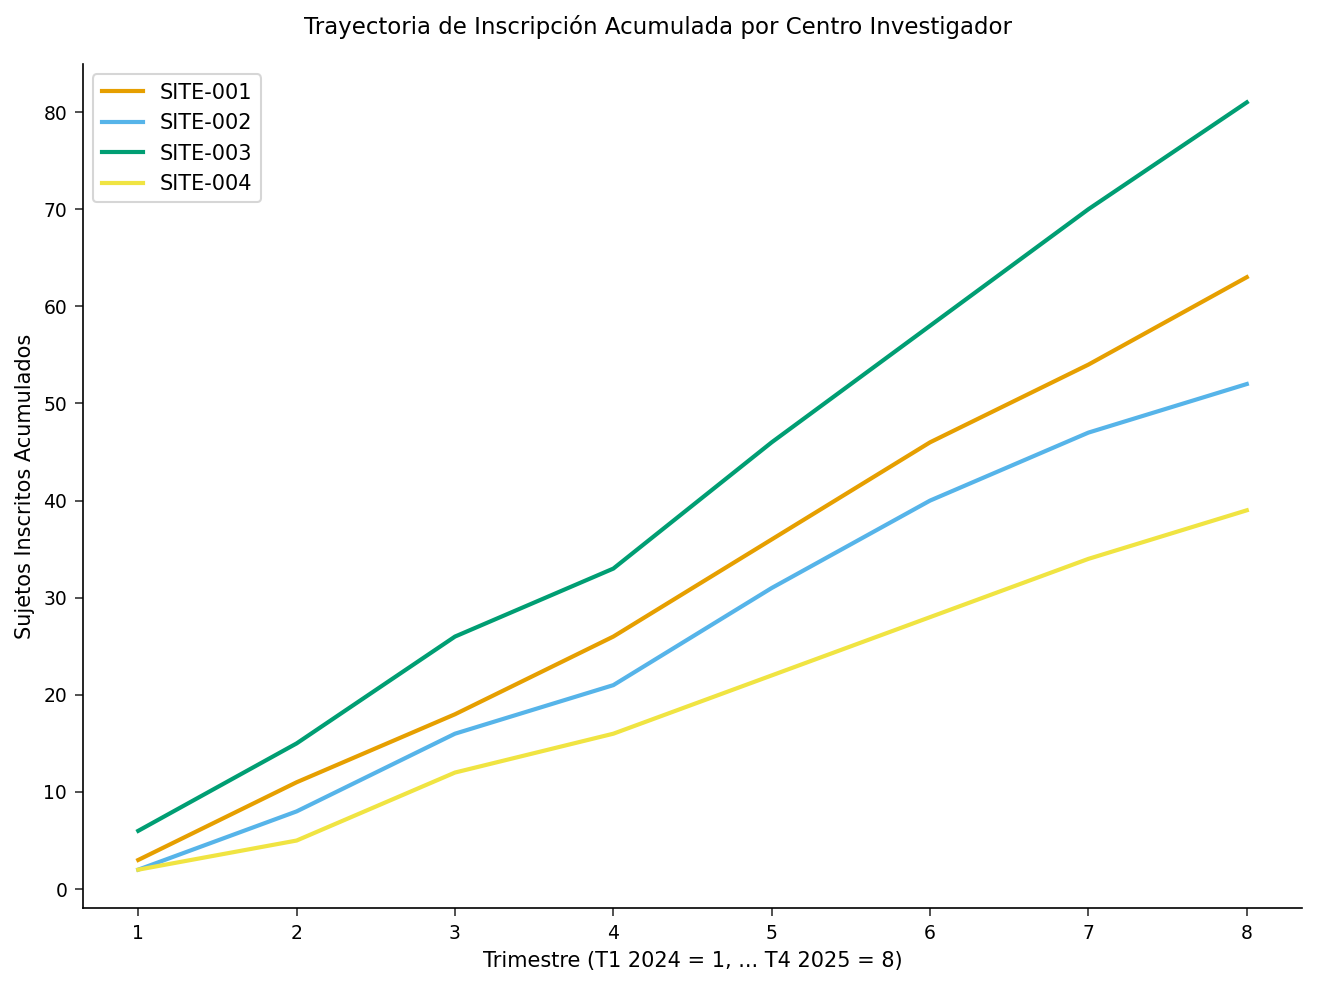

In [4]:
/* --------------------------------------------------------
   Trayectoria de inscripción acumulada trimestral por centro.
   Graficada contra un índice trimestral (1..8) para un eje
   limpio.
   -------------------------------------------------------- */
DATOS work.traj;
    ESTABLECER work.enrollment_qtr;
    POR site_id;
    RETENER quarter_index 0;
    SI first.site_id ENTONCES quarter_index = 0;
    quarter_index + 1;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS ETIQUETA="Trimestre (T1 2024 = 1, ... T4 2025 = 8)"
        integer VALUES=(1 HASTA 8 POR 1);
    YAXIS ETIQUETA="Sujetos Inscritos Acumulados";
    TÍTULO "Trayectoria de Inscripción Acumulada por Centro Investigador";
EJECUTAR;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND requiere que la variable ID esté ordenada
   dentro de cada grupo BY, así que ordenar por centro y
   luego trimestre antes de convertir.
   -------------------------------------------------------- */
PROCEDIMIENTO ORDENAR DATOS=work.enrollment_qtr;
    POR site_id quarter_date;
EJECUTAR;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Convertir la inscripción trimestral a estimaciones
   mensuales.

   FROM=QTR / TO=MONTH en la instrucción PROC fijan las
   frecuencias de entrada y salida; PROC EXPAND interpola
   cada grupo BY (centro) de forma independiente a lo largo
   de la fecha ID.

   enrolled_count      -> METHOD=JOIN   (lineal por tramos; el
                          valor de flujo se mantiene no negativo
                          entre anclas)
   cumulative_enrolled -> METHOD=SPLINE (curva monótona suave)
   -------------------------------------------------------- */
PROCEDIMIENTO expand DATOS=work.enrollment_qtr
            out=work.enrollment_monthly
            DESDE=qtr HASTA=month;
    POR site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=END     METHOD=SPLINE;
EJECUTAR;


                                    Referencia de Inscripción Trimestral por Región                                     




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                    Referencia de Inscripción Trimestral por Región                                     




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


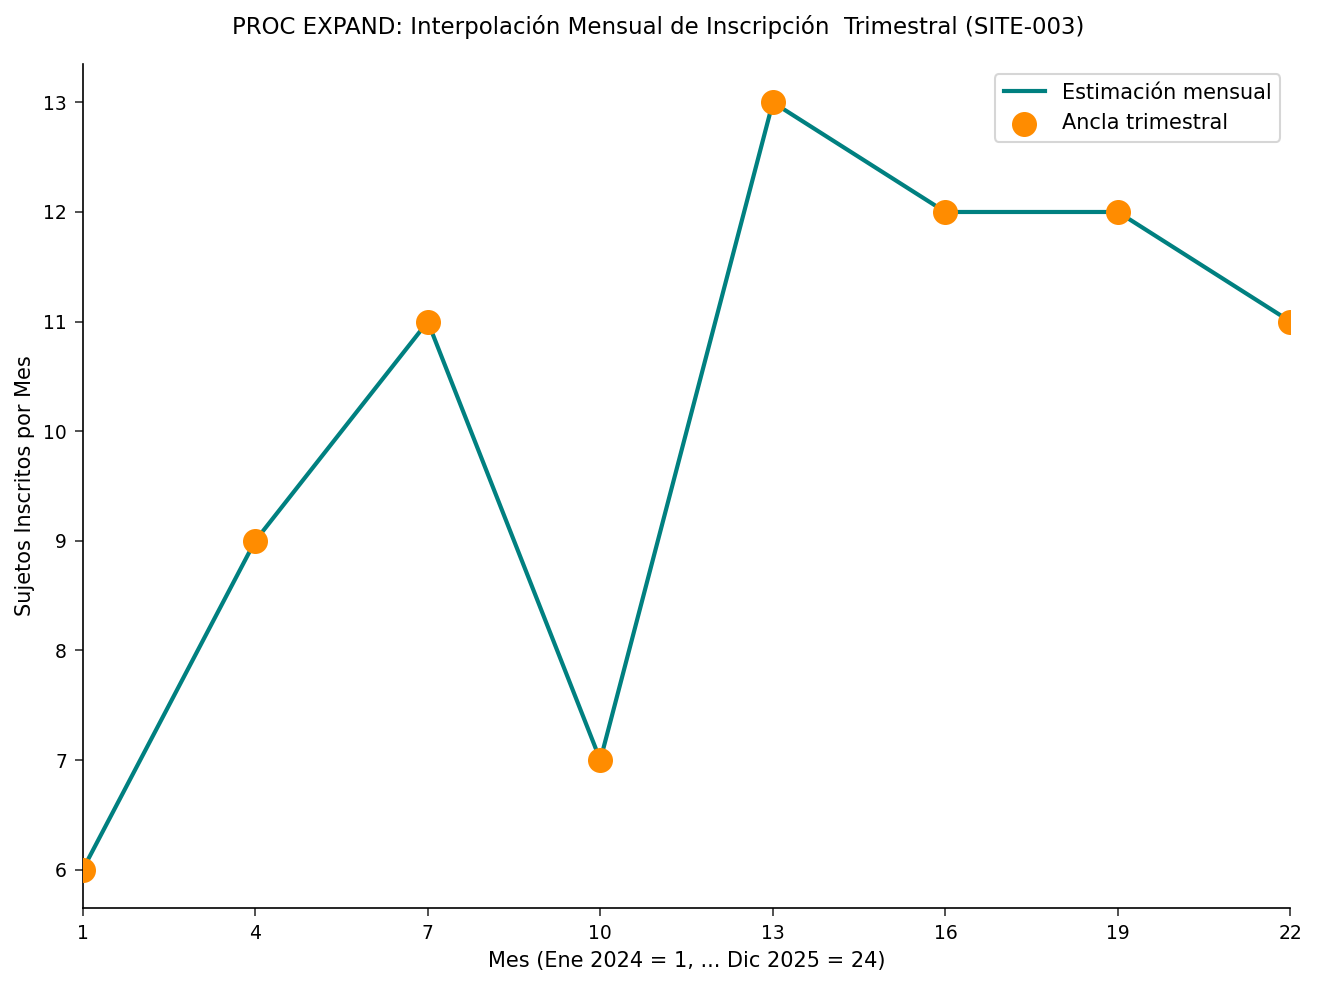

In [7]:
/* --------------------------------------------------------
   La variable ID ahora contiene fechas mensuales. Volver a
   formatearla y agregar un índice mensual dentro de cada
   centro (1..24) para graficar.
   -------------------------------------------------------- */
DATOS work.enrollment_monthly;
    ESTABLECER work.enrollment_monthly;
    POR site_id;
    FORMATO month_date monyy7.;
    month_date = quarter_date;
    RETENER month_index 0;
    SI first.site_id ENTONCES month_index = 0;
    month_index + 1;
    /* marcar los meses ancla trimestrales (1, 4, 7, ...) */
    SI mod(month_index - 1, 3) = 0 ENTONCES anchor = enrolled_count;
    SINO anchor = .;
EJECUTAR;

/* Mostrar la conversión para un centro: línea mensual
   interpolada que pasa por los puntos ancla trimestrales
   originales. */
PROCEDIMIENTO SGPLOT DATOS=work.enrollment_monthly;
    DONDE site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel="Estimación mensual";
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel="Ancla trimestral";
    XAXIS ETIQUETA="Mes (Ene 2024 = 1, ... Dic 2025 = 24)"
        integer VALUES=(1 HASTA 24 POR 3);
    YAXIS ETIQUETA="Sujetos Inscritos por Mes";
    TÍTULO "PROC EXPAND: Interpolación Mensual de Inscripción "
        "Trimestral (SITE-003)";
EJECUTAR;


In [8]:
/* --------------------------------------------------------
   Unir las estimaciones mensuales con los metadatos del
   centro, luego resumir la inscripción mensual por región.
   -------------------------------------------------------- */
PROCEDIMIENTO SQL;
    CREAR TABLA work.enrollment_monthly_region AS
    SELECCIONAR e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    DESDE work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER POR s.region, e.site_id, e.month_date;
QUIT;

PROCEDIMIENTO MEDIAS DATOS=work.enrollment_monthly_region n sum mean;
    CLASE region;
    VAR monthly_estimate cumulative_estimate;
    ETIQUETA region = "Región"
          monthly_estimate = "Estimación mensual"
          cumulative_estimate = "Estimación acumulada";
    SALIDA out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.region_monthly_summary noobs ETIQUETA;
    ETIQUETA region = "Región"
          total_monthly_enrolled = "Total mensual inscrito"
          avg_monthly_rate = "Tasa mensual promedio";
    TÍTULO "Estimaciones Mensuales por Región";
EJECUTAR;


                                    Referencia de Inscripción Trimestral por Región                                     

                                    Referencia de Inscripción Trimestral por Región                                     

                                                  The MEANS Procedure

                                Analysis Variable : monthly_estimate Estimación mensual

        Región                      N Obs            Sum           Mean
        ---------------------------------------------------------------
        AMÉRICA_DEL_NORTE              44    326.0000000      7.4090909
        EUROPA                         44    336.0000000      7.6363636
        ---------------------------------------------------------------

                             Analysis Variable : cumulative_estimate Estimación acumulada

        Región                      N Obs            Sum           Mean
        ---------------------------------------------------------------



NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Interpretación

PROC EXPAND convirtió los **32 registros trimestrales** (4 centros x 8 trimestres) en **96 registros mensuales** mediante conversión de frecuencia a lo largo de la fecha de cada centro. La serie mensual interpolada pasa exactamente por los valores de anclaje trimestrales originales, como muestra el gráfico de SITE-003: los puntos naranjas son los ocho recuentos trimestrales reportados y la línea verde azulada es la estimación mensual desagregada que los conecta.

En términos mensuales, las dos regiones evolucionan de forma muy similar. Europa promedia **7.64** sujetos reclutados por centro-mes y Norteamérica **7.41**, con totales mensuales regionales de **336** y **326** sujetos a lo largo del horizonte interpolado. Como `METHOD=JOIN` no extrapola más allá del último anclaje trimestral, los meses finales de trimestre parcial no llevan estimación y quedan excluidos de las medias mensuales, lo cual es la opción conservadora para la planificación prospectiva.

Estas proyecciones mensuales permiten que las operaciones clínicas pasen de una cadencia de planificación trimestral a una mensual -- dimensionando los envíos de suministro de fármacos, programando las visitas de monitorización e informando el reclutamiento al Comité de Monitorización de Datos y Seguridad -- sin reformular ninguna de las cifras trimestrales que el estudio ya ha bloqueado.

---

In [9]:
/* --------------------------------------------------------
   Exportar las proyecciones de inscripción mensual para
   herramientas de planificación posteriores.
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
EJECUTAR;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>